#  Mão na Roda — Análise Exploratória do Dataset

**Universidade Presbiteriana Mackenzie**  
Faculdade de Computação e Informática  
Disciplina: Inteligência Artificial — 7ºN CC (Noite)  
Professor: Prof. Dr. Ivan Carlos Alcântara de Oliveira

---

**Projeto:** Mão na Roda — Sistema Inteligente para Diagnóstico Preliminar de Falhas Automotivas Baseado em PLN e Machine Learning

| Integrante | RA | E-mail |
|---|---|---|
| Diego Spagnuolo Sugai | 10417329 | diegossugai@gmail.com |
| Kauê Henrique Matias Alves | 10417894 | kauehmalves@gmail.com |
| Leonardo Moreira dos Santos | 10417555 | leonardomsantos12@gmail.com |
| Victor Maki Tarcha | 10419861 | victormakitarcha@gmail.com |

---

**Arquivo:** `analise_exploratoria.ipynb`  
**Síntese:** Análise exploratória completa do dataset de relatos automotivos em português brasileiro. Abrange: inspeção geral, distribuição de classes, análise de urgência, variação linguística, comprimento dos relatos, frequência de termos e faixa de custo estimado por falha. Gera 8 figuras salvas em `./figuras/`.

**Histórico de alterações:**
- `2026-03-29` | Diego Sugai — Criação do arquivo e estrutura inicial  
- `2026-03-29` | Kauê Alves — Adição das análises de custo e urgência  
- `2026-03-29` | Leonardo Santos — Adição do heatmap e análise de frequência  
- `2026-03-29` | Victor Tarcha — Revisão geral, ajustes de estilo e exportação  

---
## Seção 0 — Instalação de dependências e upload do dataset

In [1]:
# Instalar dependências (caso necessário no Colab)
# pandas, numpy e matplotlib já vêm pré-instalados no Colab
# Caso precise forçar versões específicas, descomente:
# !pip install pandas numpy matplotlib --quiet

In [2]:
# ─── Upload do dataset para o Colab ─────────────────────────────────────────
# Execute esta célula para fazer o upload do arquivo 'dataset_mao_na_roda.xlsx'
# (ou .csv) diretamente para o ambiente do Colab.

from google.colab import files
import io

print(' Selecione o arquivo dataset_mao_na_roda.xlsx (ou .csv):')
uploaded = files.upload()

print('\n Arquivos carregados:', list(uploaded.keys()))

 Selecione o arquivo dataset_mao_na_roda.xlsx (ou .csv):


Saving dataset_mao_na_roda.xlsx to dataset_mao_na_roda.xlsx

 Arquivos carregados: ['dataset_mao_na_roda.xlsx']


---
##  Seção 1 — Importações e Configurações Globais

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import MaxNLocator
from collections import Counter
import re
import os
import warnings

warnings.filterwarnings('ignore')

# No Colab, o matplotlib exibe inline automaticamente
%matplotlib inline

# Diretório de saída das figuras
OUTPUT_DIR = 'figuras'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Paleta de cores — uma cor por classe (0 a 9) ───────────────────────────
PALETTE = [
    '#F4D03F',  # 0 Bateria/Elétrico
    '#E74C3C',  # 1 Freios
    '#C0392B',  # 2 Superaquecimento
    '#2ECC71',  # 3 Suspensão
    '#3498DB',  # 4 Transmissão/Câmbio
    '#9B59B6',  # 5 Vazamento de Óleo
    '#1ABC9C',  # 6 Arrefecimento
    '#E67E22',  # 7 Pneu/Roda
    '#F39C12',  # 8 Injeção/Combustível
    '#8E44AD',  # 9 Escapamento
]

URGENCY_COLORS = {
    'critico': '#C0392B',
    'alto':    '#E67E22',
    'medio':   '#F4D03F',
    'baixo':   '#2ECC71',
}

# ── Stopwords em português (lista manual — sem dependência de NLTK) ─────────
STOPWORDS_PT = {
    'o','a','os','as','e','de','do','da','dos','das','em','no','na','nos','nas',
    'um','uma','que','se','por','com','para','ao','aos','à','às','ou','mas','mais',
    'não','nao','num','numa','é','tá','tô','meu','minha','meus','minhas','quando',
    'depois','antes','muito','bem','todo','toda','tudo','já','só','lá','cá','pra',
    'pro','pras','pros','isso','esse','essa','esses','essas','este','esta','estes',
    'estas','foi','fui','tem','ter','ser','ir','eu','ele','ela','eles','elas','me',
    'te','nos','vos','lhe','lhes','também','mesmo','sempre','cada','entre','até',
    'sobre','então','porque','disso','desse','dessa','aqui','ali','aí','onde',
    'como','quanto','ficou','ficando','está','estou','estão','tinha','tenho',
    'faiz','tou','bom','ruim',
}

print(' Importações e configurações concluídas!')

 Importações e configurações concluídas!


---
##  Seção 2 — Carregamento e Inspeção Inicial do Dataset

In [5]:
# ── Detecção automática do formato (xlsx ou csv) ───────────────────────────
import glob

xlsx_files = glob.glob('*.xlsx') + glob.glob('dataset*.xlsx')
csv_files  = glob.glob('*.csv')  + glob.glob('dataset*.csv')

if xlsx_files:
    DATASET_PATH = xlsx_files[0]
    df = pd.read_excel(DATASET_PATH)
    print(f' Dataset carregado (Excel): {DATASET_PATH}')
elif csv_files:
    DATASET_PATH = csv_files[0]
    df = pd.read_csv(DATASET_PATH, encoding='utf-8-sig')
    print(f' Dataset carregado (CSV): {DATASET_PATH}')
else:
    raise FileNotFoundError(' Dataset não encontrado. Execute a célula de upload acima.')

# ── Diagnóstico: exibe colunas originais antes de qualquer renomeação ───────
print(f'\n Colunas originais do arquivo: {list(df.columns)}')

# ── Padronização dos nomes de colunas ───────────────────────────────────────
# O dataset usa nomes longos/descritivos; aqui mapeamos para os nomes
# internos usados pelo código (snake_case curto).
COLMAP = {
    'ID':                      'id',
    'Relato (Sintoma PT-BR)':  'relato',
    'Classe (Label)':          'falha_label',
    'Falha Diagnosticada':     'falha_descricao',
    'Custo Mín (R$)':          'custo_min_brl',
    'Custo Máx (R$)':          'custo_max_brl',
    'Custo Médio (R$)':        'custo_medio_brl',
    'Urgência':                'nivel_urgencia',
    'Tipo Linguístico':        'variacao_linguistica',
}
df.rename(columns=COLMAP, inplace=True)
print(f' Colunas após padronização: {list(df.columns)}')

# ── Engenharia de features de texto ───────────────────────────────────────
df['num_palavras'] = df['relato'].apply(lambda x: len(str(x).split()))
df['num_chars']    = df['relato'].apply(len)

CLASS_NAMES = df.groupby('falha_label')['falha_descricao'].first().to_dict()

print(f'\n Shape do dataset  : {df.shape}')
print(f' Colunas           : {list(df.columns)}')
print(f' Valores nulos     : {df.isnull().sum().sum()}')
print(f' Duplicatas        : {df.duplicated(subset="relato").sum()}')
print(f'  Número de classes : {df["falha_label"].nunique()}')

 Dataset carregado (Excel): dataset_mao_na_roda.xlsx

 Colunas originais do arquivo: ['ID', 'Relato (Sintoma PT-BR)', 'Classe (Label)', 'Falha Diagnosticada', 'Custo Mín (R$)', 'Custo Máx (R$)', 'Custo Médio (R$)', 'Urgência', 'Tipo Linguístico']
 Colunas após padronização: ['id', 'relato', 'falha_label', 'falha_descricao', 'custo_min_brl', 'custo_max_brl', 'custo_medio_brl', 'nivel_urgencia', 'variacao_linguistica']

 Shape do dataset  : (170, 11)
 Colunas           : ['id', 'relato', 'falha_label', 'falha_descricao', 'custo_min_brl', 'custo_max_brl', 'custo_medio_brl', 'nivel_urgencia', 'variacao_linguistica', 'num_palavras', 'num_chars']
 Valores nulos     : 0
 Duplicatas        : 0
  Número de classes : 10


In [6]:
# ── Tipos de dados ─────────────────────────────────────────────────────────
print(' Tipos de dados:')
display(df.dtypes.to_frame('Tipo'))

print('\n Primeiras 5 linhas do dataset:')
display(df.head())

 Tipos de dados:


,Tipo
id,int64
relato,object
falha_label,int64
falha_descricao,object
custo_min_brl,int64
custo_max_brl,int64
custo_medio_brl,int64
nivel_urgencia,object
variacao_linguistica,object
num_palavras,int64



 Primeiras 5 linhas do dataset:


,id,relato,falha_label,falha_descricao,custo_min_brl,custo_max_brl,custo_medio_brl,nivel_urgencia,variacao_linguistica,num_palavras,num_chars
0,1,"O carro não liga de jeito nenhum, só dá um cli...",0,Bateria/Sistema Elétrico,150,600,375,alto,formal,15,69
1,2,"meu carro num liga nao, da so um tique quando ...",0,Bateria/Sistema Elétrico,150,600,375,alto,informal_erro_ortografico,13,58
2,3,"bateria morreu de novo, já é a terceira vez es...",0,Bateria/Sistema Elétrico,150,600,375,alto,informal,11,52
3,4,as luzes do painel piscam e o carro morre no s...,0,Bateria/Sistema Elétrico,150,800,475,alto,formal,11,53
4,5,"o alternador tá zuado, bateria não carrega",0,Bateria/Sistema Elétrico,300,900,600,alto,giria,7,42


In [7]:
# ── Estatísticas descritivas ───────────────────────────────────────────────
print(' Estatísticas descritivas — variáveis numéricas:')
display(df[['custo_min_brl','custo_max_brl','custo_medio_brl',
            'num_palavras','num_chars']].describe().round(2))

 Estatísticas descritivas — variáveis numéricas:


,custo_min_brl,custo_max_brl,custo_medio_brl,num_palavras,num_chars
count,170.00,170.00,170.00,170.00,170.00
mean,286.76,1771.18,1028.97,9.47,54.45
std,336.99,1782.97,1042.78,1.73,7.38
min,0.00,100.00,50.00,5.00,36.00
25%,100.00,725.00,431.25,8.00,49.00
50%,200.00,1200.00,750.00,9.00,54.00
75%,300.00,2000.00,1100.00,11.00,59.75
max,2000.00,10000.00,6000.00,15.00,76.00


In [8]:
# ── Distribuição de classes ────────────────────────────────────────────────
print('  Distribuição de Classes:')
for label, name in sorted(CLASS_NAMES.items()):
    n = (df['falha_label'] == label).sum()
    print(f'  Classe {label} — {name:<38} : {n:>3} relatos ({n/len(df)*100:.1f}%)')

print(f'\n Distribuição por Urgência:')
display(df['nivel_urgencia'].value_counts().to_frame('Quantidade'))

print(f'\n Distribuição por Variação Linguística:')
display(df['variacao_linguistica'].value_counts().to_frame('Quantidade'))

print(f'\n Comprimento dos Relatos (palavras):')
print(f'  Média   : {df["num_palavras"].mean():.1f}')
print(f'  Mediana : {df["num_palavras"].median():.0f}')
print(f'  Mínimo  : {df["num_palavras"].min()}')
print(f'  Máximo  : {df["num_palavras"].max()}')
print(f'  Desvio  : {df["num_palavras"].std():.1f}')

  Distribuição de Classes:
  Classe 0 — Bateria/Sistema Elétrico               :  17 relatos (10.0%)
  Classe 1 — Sistema de Freios                      :  19 relatos (11.2%)
  Classe 2 — Superaquecimento do Motor              :  16 relatos (9.4%)
  Classe 3 — Suspensão/Amortecedores                :  17 relatos (10.0%)
  Classe 4 — Sistema de Transmissão/Câmbio          :  17 relatos (10.0%)
  Classe 5 — Vazamento de Óleo                      :  17 relatos (10.0%)
  Classe 6 — Sistema de Arrefecimento               :  16 relatos (9.4%)
  Classe 7 — Pneu/Roda                              :  17 relatos (10.0%)
  Classe 8 — Sistema de Injeção/Combustível         :  18 relatos (10.6%)
  Classe 9 — Sistema de Escapamento                 :  16 relatos (9.4%)

 Distribuição por Urgência:


,Quantidade
nivel_urgencia,
alto,90
medio,48
critico,28
baixo,4



 Distribuição por Variação Linguística:


,Quantidade
variacao_linguistica,
formal,83
informal,50
giria,19
informal_erro_ortografico,17
ambiguo,1



 Comprimento dos Relatos (palavras):
  Média   : 9.5
  Mediana : 9
  Mínimo  : 5
  Máximo  : 15
  Desvio  : 1.7


---
##  Seção 3 — Funções Auxiliares

In [10]:
def salvar(nome):
    """Salva a figura atual no diretório de saída."""
    caminho = os.path.join(OUTPUT_DIR, nome)
    plt.savefig(caminho, dpi=150, bbox_inches='tight')
    print(f'   Figura salva: {caminho}')
    plt.show()  # Exibe inline no Colab
    plt.close()

def estilo_eixo(ax):
    """Remove bordas superiores e direita para visual limpo."""
    ax.spines[['top', 'right']].set_visible(False)

print(' Funções auxiliares definidas.')

 Funções auxiliares definidas.


---
##  Seção 4 — Visualizações

### Figura 1 — Distribuição de Relatos por Classe (barras horizontais)

   Figura salva: figuras/fig1_distribuicao_classes.png


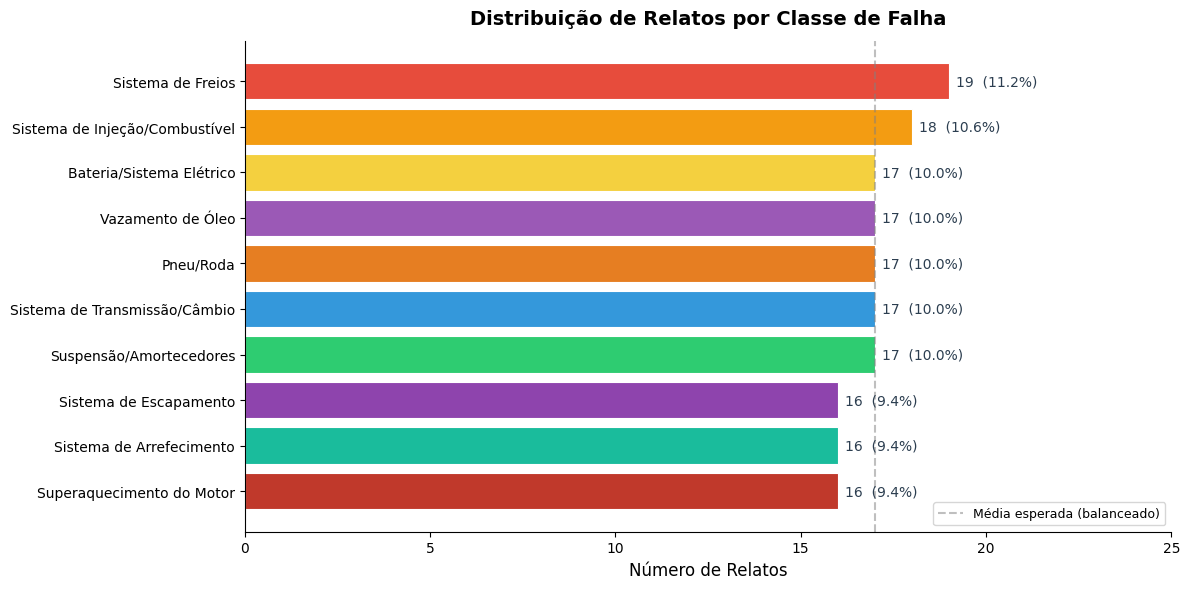

In [11]:
fig, ax = plt.subplots(figsize=(12, 6))
counts = df['falha_descricao'].value_counts().sort_values()
colors = [PALETTE[df[df['falha_descricao'] == c]['falha_label'].iloc[0]] for c in counts.index]
bars = ax.barh(counts.index, counts.values, color=colors, edgecolor='white', linewidth=0.8)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height() / 2,
            f'{val}  ({val / len(df) * 100:.1f}%)', va='center', fontsize=10, color='#2c3e50')
ax.set_xlabel('Número de Relatos', fontsize=12)
ax.set_title('Distribuição de Relatos por Classe de Falha', fontsize=14,
             fontweight='bold', pad=12)
ax.set_xlim(0, counts.max() + 6)
ax.axvline(len(df) / 10, color='gray', linestyle='--', alpha=0.5, label='Média esperada (balanceado)')
ax.legend(fontsize=9)
estilo_eixo(ax)
plt.tight_layout()
salvar('fig1_distribuicao_classes.png')

### Figura 2 — Urgência (pizza) e Variação Linguística (barras)

   Figura salva: figuras/fig2_urgencia_variacao.png


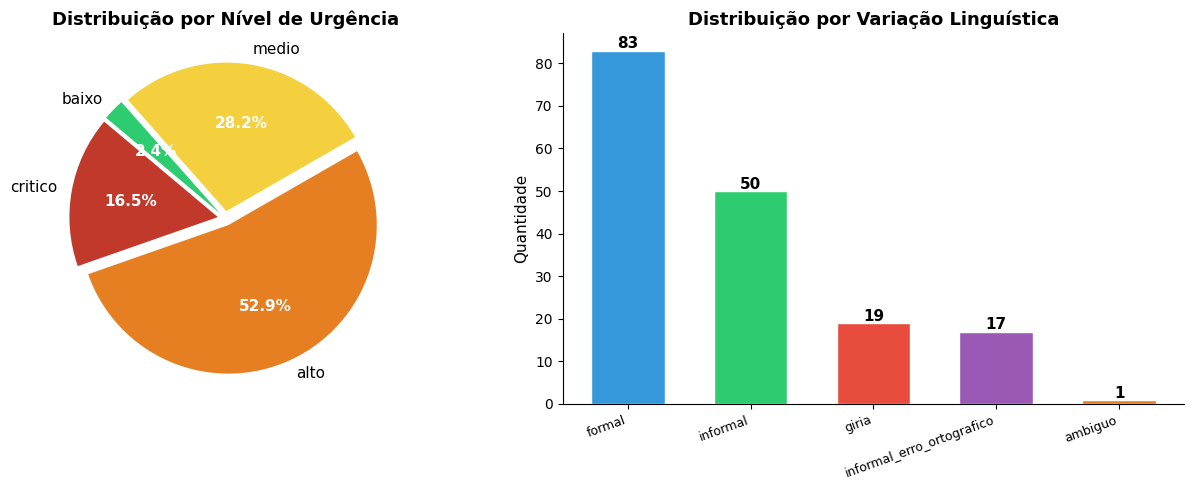

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

urg_order = ['critico', 'alto', 'medio', 'baixo']
urg = df['nivel_urgencia'].value_counts().reindex([u for u in urg_order if u in df['nivel_urgencia'].unique()])
colors_urg = [URGENCY_COLORS[u] for u in urg.index]
explode = [0.05] * len(urg)
wedges, texts, autotexts = axes[0].pie(
    urg.values, labels=urg.index, colors=colors_urg,
    autopct='%1.1f%%', startangle=140, explode=explode,
    textprops={'fontsize': 11})
for at in autotexts:
    at.set_fontweight('bold')
    at.set_color('white')
axes[0].set_title('Distribuição por Nível de Urgência', fontsize=13, fontweight='bold')

var = df['variacao_linguistica'].value_counts()
var_colors = ['#3498DB', '#2ECC71', '#E74C3C', '#9B59B6', '#E67E22'][:len(var)]
bars2 = axes[1].bar(var.index, var.values, color=var_colors, edgecolor='white', width=0.6)
for bar, val in zip(bars2, var.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 str(val), ha='center', fontsize=11, fontweight='bold')
axes[1].set_title('Distribuição por Variação Linguística', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Quantidade', fontsize=11)
axes[1].set_xticklabels(var.index, rotation=20, ha='right', fontsize=9)
estilo_eixo(axes[1])
plt.tight_layout()
salvar('fig2_urgencia_variacao.png')

### Figura 3 — Custo Estimado por Classe (boxplot)

   Figura salva: figuras/fig3_custo_boxplot.png


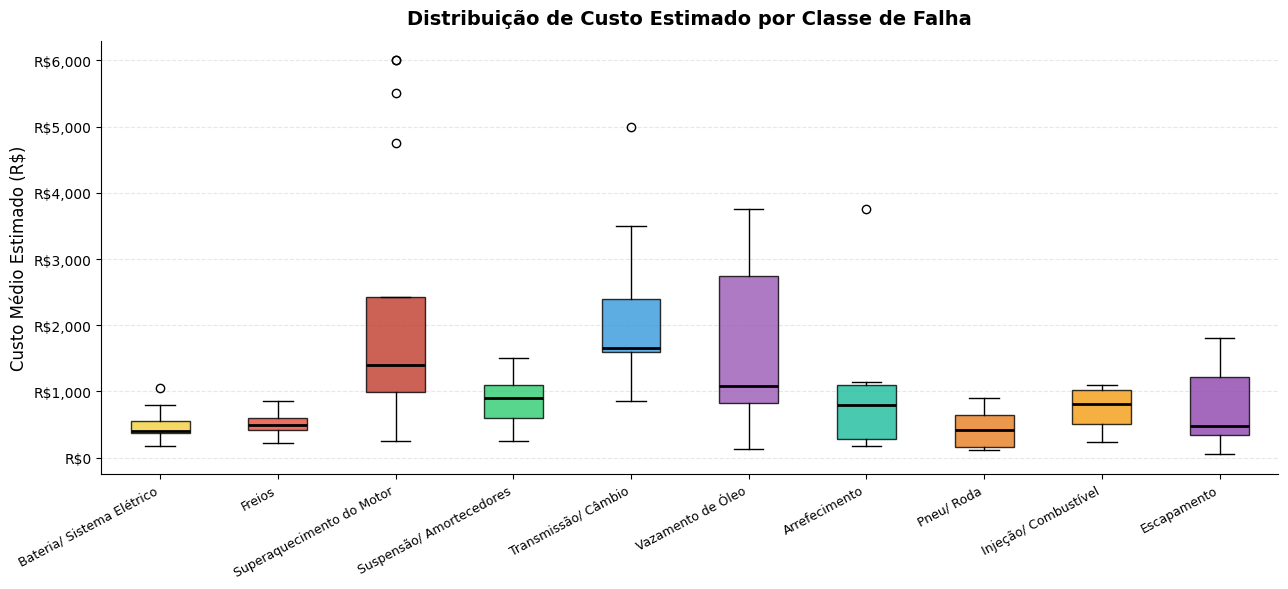

In [13]:
fig, ax = plt.subplots(figsize=(13, 6))
classes_order = [CLASS_NAMES[i] for i in sorted(CLASS_NAMES.keys())]
data_box = [df[df['falha_descricao'] == c]['custo_medio_brl'].values for c in classes_order]
bp = ax.boxplot(data_box, vert=True, patch_artist=True,
                medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], PALETTE):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
labels_short = [c.replace('Sistema de ', '').replace('/', '/ ') for c in classes_order]
ax.set_xticks(range(1, len(classes_order) + 1))
ax.set_xticklabels(labels_short, rotation=28, ha='right', fontsize=9)
ax.set_ylabel('Custo Médio Estimado (R$)', fontsize=12)
ax.set_title('Distribuição de Custo Estimado por Classe de Falha',
             fontsize=14, fontweight='bold', pad=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'R${x:,.0f}'))
ax.grid(axis='y', alpha=0.3, linestyle='--')
estilo_eixo(ax)
plt.tight_layout()
salvar('fig3_custo_boxplot.png')

### Figura 4 — Heatmap: Nível de Urgência × Classe de Falha

   Figura salva: figuras/fig4_heatmap_urgencia_classe.png


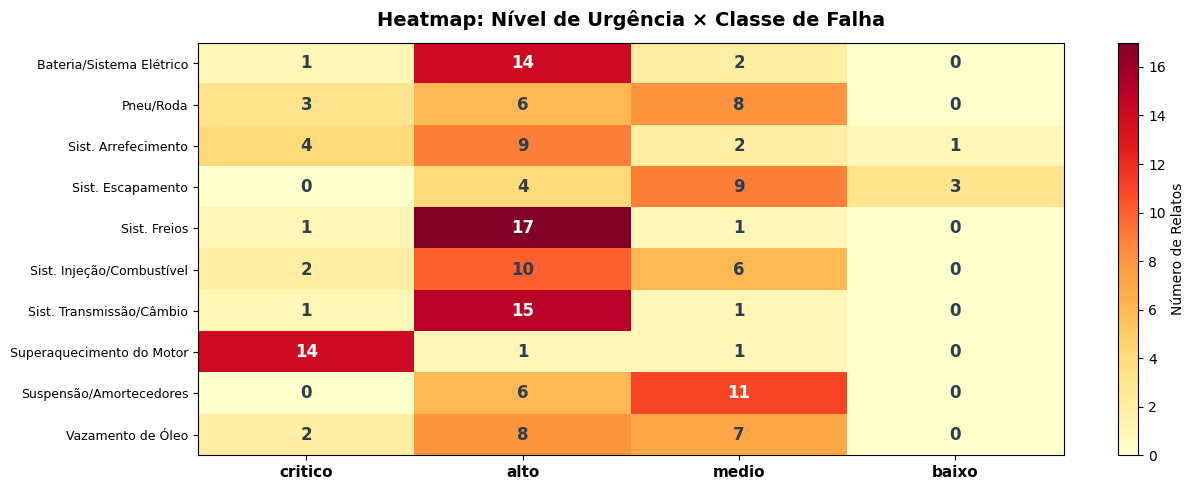

In [14]:
fig, ax = plt.subplots(figsize=(13, 5))
pivot = pd.crosstab(df['falha_descricao'], df['nivel_urgencia'])
for col in ['critico', 'alto', 'medio', 'baixo']:
    if col not in pivot.columns:
        pivot[col] = 0
pivot = pivot[['critico', 'alto', 'medio', 'baixo']]
pivot.index = [i.replace('Sistema de ', 'Sist. ') for i in pivot.index]
im = ax.imshow(pivot.values, cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, fontsize=11, fontweight='bold')
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=9)
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        val = pivot.values[i, j]
        color = 'white' if val > pivot.values.max() * 0.6 else '#2c3e50'
        ax.text(j, i, str(val), ha='center', va='center',
                fontsize=12, fontweight='bold', color=color)
plt.colorbar(im, ax=ax, label='Número de Relatos')
ax.set_title('Heatmap: Nível de Urgência × Classe de Falha',
             fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
salvar('fig4_heatmap_urgencia_classe.png')

### Figura 5 — Comprimento dos Relatos (histograma + média por classe)

   Figura salva: figuras/fig5_tamanho_relatos.png


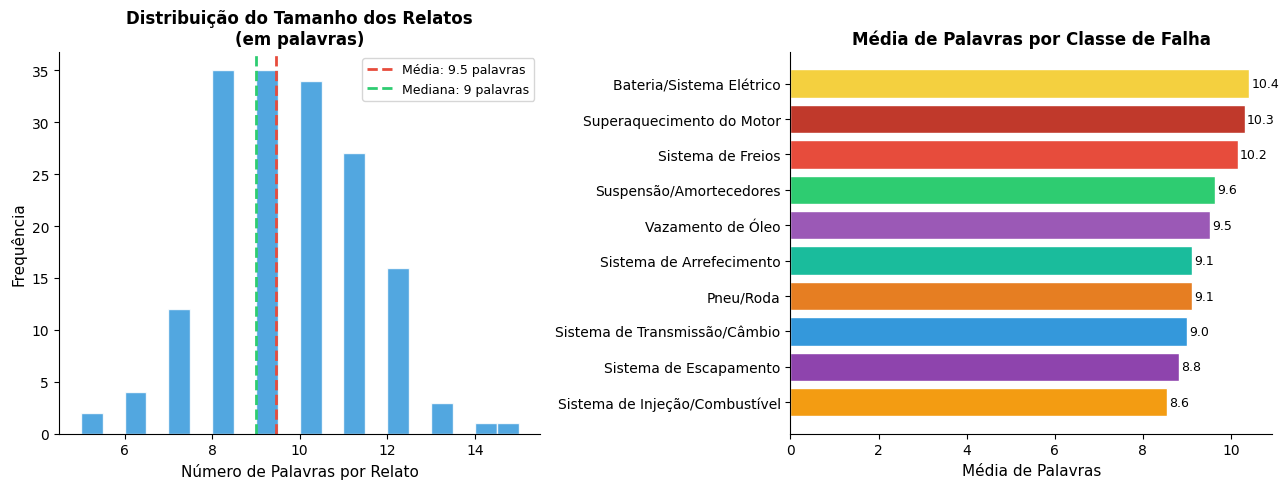

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(df['num_palavras'], bins=20, color='#3498DB', edgecolor='white', alpha=0.85)
axes[0].axvline(df['num_palavras'].mean(), color='#E74C3C', linestyle='--', linewidth=2,
                label=f"Média: {df['num_palavras'].mean():.1f} palavras")
axes[0].axvline(df['num_palavras'].median(), color='#2ECC71', linestyle='--', linewidth=2,
                label=f"Mediana: {df['num_palavras'].median():.0f} palavras")
axes[0].set_xlabel('Número de Palavras por Relato', fontsize=11)
axes[0].set_ylabel('Frequência', fontsize=11)
axes[0].set_title('Distribuição do Tamanho dos Relatos\n(em palavras)', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)
estilo_eixo(axes[0])

mean_words = df.groupby('falha_descricao')['num_palavras'].mean().sort_values()
colors_mw  = [PALETTE[df[df['falha_descricao'] == c]['falha_label'].iloc[0]] for c in mean_words.index]
axes[1].barh(mean_words.index, mean_words.values, color=colors_mw, edgecolor='white')
axes[1].set_xlabel('Média de Palavras', fontsize=11)
axes[1].set_title('Média de Palavras por Classe de Falha', fontsize=12, fontweight='bold')
for i, v in enumerate(mean_words.values):
    axes[1].text(v + 0.05, i, f'{v:.1f}', va='center', fontsize=9)
estilo_eixo(axes[1])
plt.tight_layout()
salvar('fig5_tamanho_relatos.png')

### Figura 6 — Top 30 Termos Mais Frequentes (sem stopwords)

   Figura salva: figuras/fig6_frequencia_palavras.png


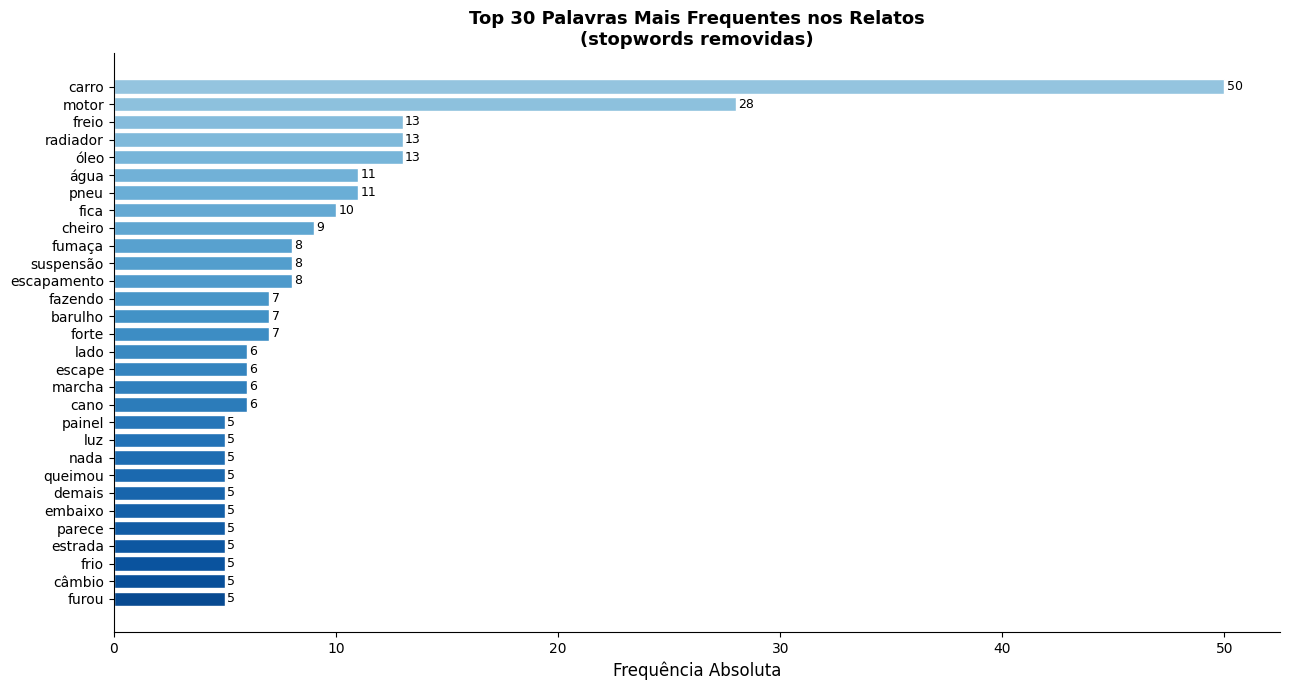

In [16]:
all_words = []
for relato in df['relato']:
    tokens = re.findall(r'\b[a-záéíóúãõâêôàüç]{3,}\b', str(relato).lower())
    all_words.extend([w for w in tokens if w not in STOPWORDS_PT])

word_freq = Counter(all_words).most_common(30)
words_30, freqs_30 = zip(*word_freq)

fig, ax = plt.subplots(figsize=(13, 7))
gradient_colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(words_30)))[::-1]
bars = ax.barh(list(words_30)[::-1], list(freqs_30)[::-1],
               color=gradient_colors, edgecolor='white')
for bar, val in zip(bars, list(freqs_30)[::-1]):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
            str(val), va='center', fontsize=9)
ax.set_xlabel('Frequência Absoluta', fontsize=12)
ax.set_title('Top 30 Palavras Mais Frequentes nos Relatos\n(stopwords removidas)', fontsize=13, fontweight='bold')
estilo_eixo(ax)
plt.tight_layout()
salvar('fig6_frequencia_palavras.png')

### Figura 7 — Análise de Custo: Médio por Urgência + Scatter Min vs Max

   Figura salva: figuras/fig7_custo_urgencia_scatter.png


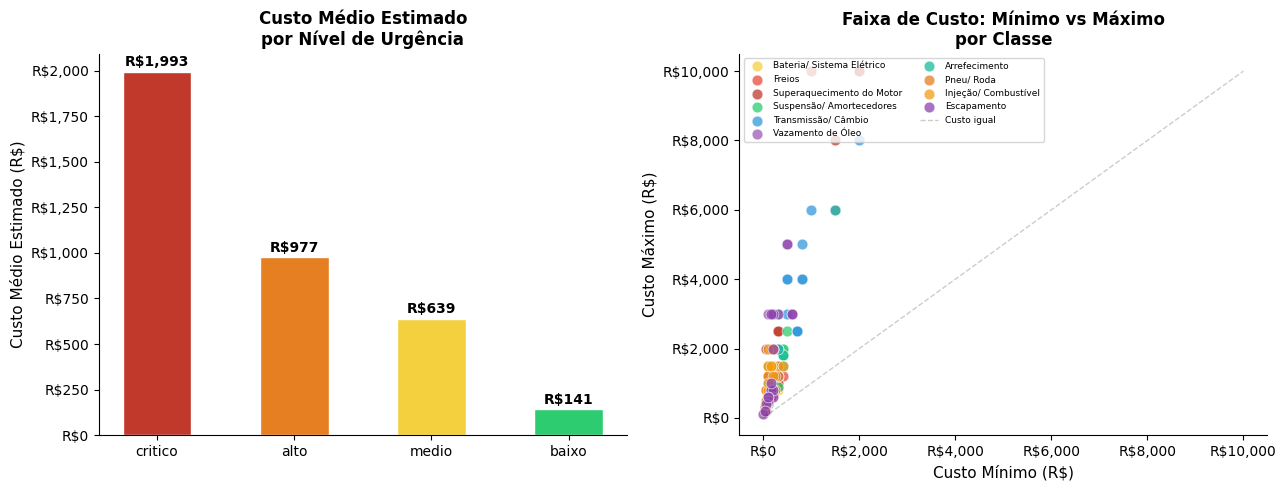

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

urg_cost = (df.groupby('nivel_urgencia')['custo_medio_brl']
              .mean().reindex(['critico', 'alto', 'medio', 'baixo']))
colors_uc = [URGENCY_COLORS[u] for u in urg_cost.index]
bars = axes[0].bar(urg_cost.index, urg_cost.values, color=colors_uc,
                   edgecolor='white', width=0.5)
for bar, val in zip(bars, urg_cost.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
                 f'R${val:,.0f}', ha='center', fontsize=10, fontweight='bold')
axes[0].set_ylabel('Custo Médio Estimado (R$)', fontsize=11)
axes[0].set_title('Custo Médio Estimado\npor Nível de Urgência', fontsize=12, fontweight='bold')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'R${x:,.0f}'))
estilo_eixo(axes[0])

for label, group in df.groupby('falha_label'):
    axes[1].scatter(group['custo_min_brl'], group['custo_max_brl'],
                    c=PALETTE[label],
                    label=CLASS_NAMES[label].replace('Sistema de ', '').replace('/', '/ '),
                    alpha=0.75, s=60, edgecolors='white', linewidths=0.5)
axes[1].plot([0, 10000], [0, 10000], 'k--', alpha=0.2, linewidth=1, label='Custo igual')
axes[1].set_xlabel('Custo Mínimo (R$)', fontsize=11)
axes[1].set_ylabel('Custo Máximo (R$)', fontsize=11)
axes[1].set_title('Faixa de Custo: Mínimo vs Máximo\npor Classe', fontsize=12, fontweight='bold')
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'R${x:,.0f}'))
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'R${x:,.0f}'))
axes[1].legend(fontsize=6.5, loc='upper left', ncol=2)
estilo_eixo(axes[1])
plt.tight_layout()
salvar('fig7_custo_urgencia_scatter.png')

### Figura 8 — Heatmap de Frequência Relativa dos Top-20 Termos por Classe

   Figura salva: figuras/fig8_heatmap_termos_classe.png


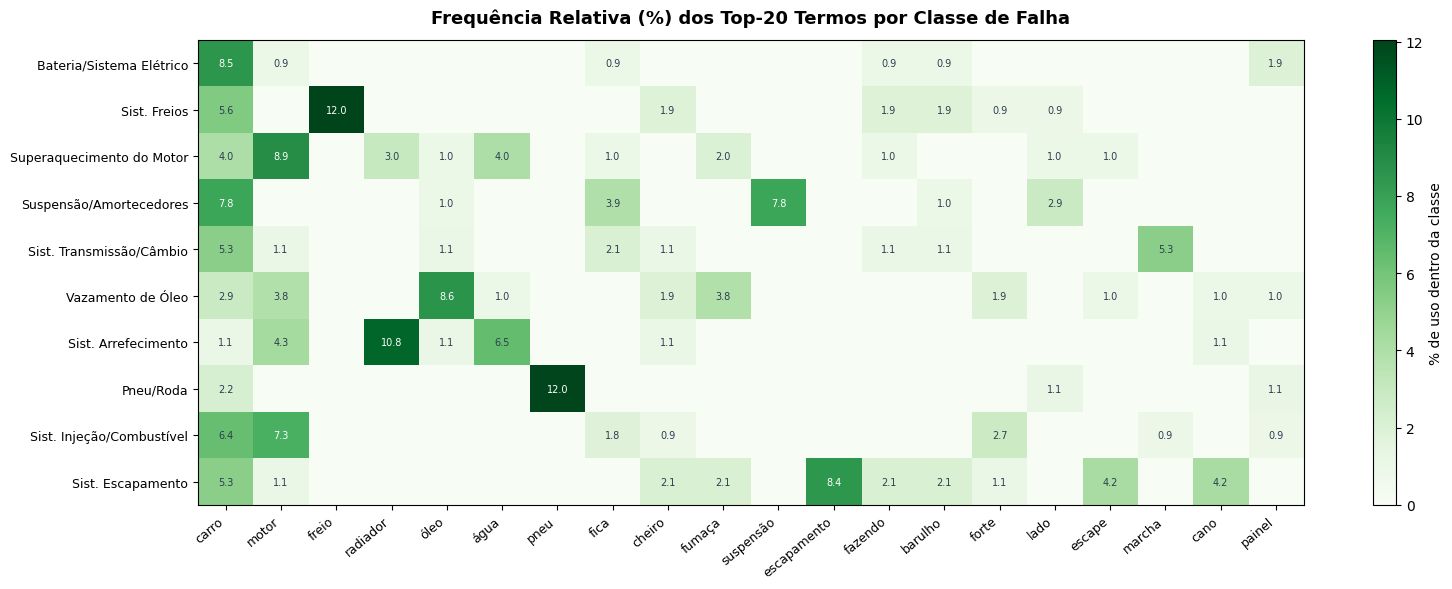

In [18]:
# Montar matriz: linhas = classes, colunas = top-20 palavras globais
top20 = [w for w, _ in Counter(all_words).most_common(20)]
matrix = np.zeros((10, 20))
for label in range(10):
    subset = df[df['falha_label'] == label]['relato']
    words_cl = []
    for relato in subset:
        tokens = re.findall(r'\b[a-záéíóúãõâêôàüç]{3,}\b', str(relato).lower())
        words_cl.extend([w for w in tokens if w not in STOPWORDS_PT])
    cnt = Counter(words_cl)
    total = sum(cnt.values()) or 1
    for j, word in enumerate(top20):
        matrix[label, j] = cnt.get(word, 0) / total * 100  # % dentro da classe

fig, ax = plt.subplots(figsize=(16, 6))
im = ax.imshow(matrix, cmap='Greens', aspect='auto')
ax.set_xticks(range(20))
ax.set_xticklabels(top20, rotation=40, ha='right', fontsize=9)
ax.set_yticks(range(10))
ax.set_yticklabels([CLASS_NAMES[i].replace('Sistema de ', 'Sist. ') for i in range(10)], fontsize=9)
for i in range(10):
    for j in range(20):
        val = matrix[i, j]
        color = 'white' if val > matrix.max() * 0.55 else '#2c3e50'
        if val > 0:
            ax.text(j, i, f'{val:.1f}', ha='center', va='center',
                    fontsize=7, color=color)
plt.colorbar(im, ax=ax, label='% de uso dentro da classe')
ax.set_title('Frequência Relativa (%) dos Top-20 Termos por Classe de Falha',
             fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
salvar('fig8_heatmap_termos_classe.png')

---
##  Seção 5 — Sumário Final e Download das Figuras

In [20]:
print('=' * 65)
print('  ANÁLISE EXPLORATÓRIA CONCLUÍDA')
print('=' * 65)
print(f'  Dataset: {len(df)} relatos | {df["falha_label"].nunique()} classes')
print(f'  Urgência crítica + alta : {((df["nivel_urgencia"].isin(["critico","alto"])).sum())} relatos ({(df["nivel_urgencia"].isin(["critico","alto"])).mean()*100:.0f}%)')
print(f'  Relatos com erros ortog.: {(df["variacao_linguistica"]=="informal_erro_ortografico").sum()}')
print(f'  Relatos com gírias      : {(df["variacao_linguistica"]=="giria").sum()}')
print(f'  Custo mínimo no dataset : R${df["custo_min_brl"].min()}')
print(f'  Custo máximo no dataset : R${df["custo_max_brl"].max():,}')
print(f'  Figuras salvas em       : ./{OUTPUT_DIR}/')
print('=' * 65)

# Listar figuras geradas
figs = sorted(os.listdir(OUTPUT_DIR))
print(f'\n {len(figs)} figura(s) gerada(s):')
for f in figs:
    print(f'   • {f}')

  ANÁLISE EXPLORATÓRIA CONCLUÍDA
  Dataset: 170 relatos | 10 classes
  Urgência crítica + alta : 118 relatos (69%)
  Relatos com erros ortog.: 17
  Relatos com gírias      : 19
  Custo mínimo no dataset : R$0
  Custo máximo no dataset : R$10,000
  Figuras salvas em       : ./figuras/

 8 figura(s) gerada(s):
   • fig1_distribuicao_classes.png
   • fig2_urgencia_variacao.png
   • fig3_custo_boxplot.png
   • fig4_heatmap_urgencia_classe.png
   • fig5_tamanho_relatos.png
   • fig6_frequencia_palavras.png
   • fig7_custo_urgencia_scatter.png
   • fig8_heatmap_termos_classe.png


In [ ]:
# ── Download de todas as figuras como ZIP ──────────────────────────────────
import shutil
from google.colab import files

zip_path = 'figuras_analise_exploratoria'
shutil.make_archive(zip_path, 'zip', OUTPUT_DIR)
files.download(f'{zip_path}.zip')
print(' Download iniciado: figuras_analise_exploratoria.zip')